In [2]:
from pathlib import Path
import os
import re
import math

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, spearmanr
from scipy.optimize import curve_fit

from pathlib import Path
import sys
import importlib

project_root = Path.cwd().parent

config_path = project_root / "config"
library_path = project_root / "library"

for path in [config_path, library_path]:
    if str(path) not in sys.path:
        sys.path.append(str(path))


import neuprint


import kylie_lib as cl
import lib_compare_receptor_to_neuprint_synapses as connectome
import lib_glucl_drive as glucl

from kylie_lib import syn_specs


In [3]:
results_dir = project_root / "results" / "connectome"
results_dir.mkdir(parents=True, exist_ok=True)

hemibrain_d7_names = pd.read_csv(results_dir / "hemibrainv121_d7_names.csv")
male_d7_names = pd.read_csv(results_dir / "malev09_d7_names.csv")

In [4]:
hemibrain_d7_names.head()

,id,instance,type,status,inputs (#post),outputs (#pre),#voxels
0,911911004,L1L9R8_R,Delta7,Traced,1496,653,1405984537
1,911919917,L1L9R8_R,Delta7,Traced,1182,562,1330959441
2,5813061383,L1L9R8_R,Delta7,Traced,1322,608,1252686779
3,911574261,L1L9R8_R,Delta7,Traced,1283,579,1331108352
4,881221166,L1L9R8_R,Delta7,Traced,1285,606,1392031704


In [5]:
dataset_name = "hemibrainv1.2.1"
# dataset_name = "malev0.9"

data_dir = (
    project_root
    / "results"
    / "connectome"
    / dataset_name
    / "Delta7_per_cell"
)

csv_files = sorted(data_dir.glob("*.csv"))

all_d7_per_cell = {
    f.stem: pd.read_csv(f)
    for f in csv_files}

len(all_d7_per_cell)

42

In [6]:
summary_dir = project_root / "results" / "extracted_signals" / "q_around99"
summary_dir.mkdir(parents=True, exist_ok=True)
summary_df = pd.read_csv(summary_dir / "summary_df.csv")

In [7]:
summary_df

,glomerulus,mean_green,total_green,percentage_total_green,percentage_total_green_divided_by_d7countall,percentage_total_green_divided_by_d7%all,mean_red,total_red,percentage_total_red,percentage_total_red_divided_by_d7countall,percentage_total_red_divided_by_d7%all,total_green_avg,percentage_total_green_avg,percentage_total_green_divided_by_d7countall_avg,percentage_total_green_divided_by_d7%all_avg,total_red_avg,percentage_total_red_avg,percentage_total_red_divided_by_d7countall_avg,percentage_total_red_divided_by_d7%all_avg
0,-4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620
1,-3,5633.6,1.081626e+09,6.138868,0.131547,9.140853,15844.2,1.550587e+10,6.468171,0.138604,9.631191,4.506776e+07,0.255786,0.005481,0.380869,6.460779e+08,0.269507,0.005775,0.401300
2,-2,5480.3,7.705925e+08,4.261698,0.125829,8.414223,13552.1,1.078569e+10,4.396369,0.129805,8.680115,3.210802e+07,0.177571,0.005243,0.350593,4.494037e+08,0.183182,0.005409,0.361671
3,-1,5240.3,5.205232e+08,2.835668,0.134650,8.475356,12912.1,7.555939e+09,3.006112,0.142744,8.984785,2.168847e+07,0.118153,0.005610,0.353140,3.148308e+08,0.125255,0.005948,0.374366
4,0,6467.2,4.155966e+09,24.000000,0.553998,36.679635,29055.2,5.983264e+10,24.000000,0.553998,36.679635,1.731652e+08,1.000000,0.023083,1.528318,2.493027e+09,1.000000,0.023083,1.528318
5,1,5429.3,4.882501e+08,2.760540,0.130713,8.512495,14139.2,8.720132e+09,3.464934,0.164067,10.684588,2.034375e+07,0.115022,0.005446,0.354687,3.633388e+08,0.144372,0.006836,0.445191
6,2,5972.6,9.532534e+08,5.426323,0.161807,10.935027,16646.4,1.273110e+10,5.100357,0.152087,10.278147,3.971889e+07,0.226097,0.006742,0.455626,5.304625e+08,0.212515,0.006337,0.428256
7,3,6254.2,1.074362e+09,6.332541,0.133685,9.120794,17753.2,1.520261e+10,6.361438,0.134295,9.162414,4.476508e+07,0.263856,0.005570,0.380033,6.334419e+08,0.265060,0.005596,0.381767
8,4,5860.3,1.128170e+09,6.526031,0.146849,10.137437,17500.1,1.623735e+10,6.730389,0.151447,10.454883,4.700709e+07,0.271918,0.006119,0.422393,6.765564e+08,0.280433,0.006310,0.435620


In [8]:
d7_input_matrix = glucl.build_d7_input_matrix(
    delta_name=hemibrain_d7_names,   # or your demibrain_df_names
    input_dict=all_d7_per_cell,)

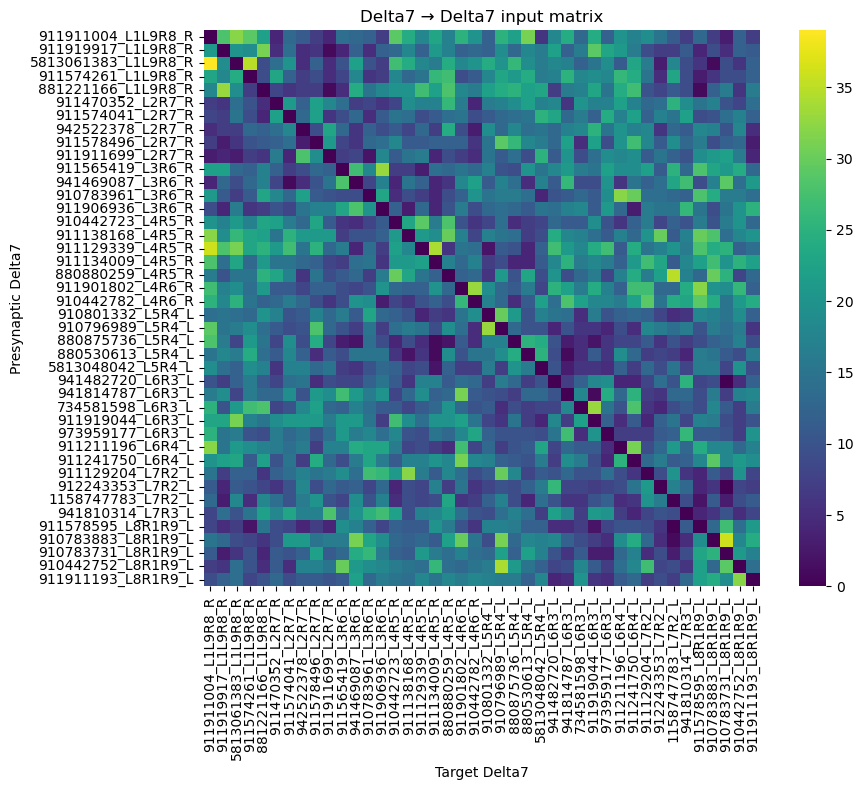

In [9]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    d7_input_matrix,
    cmap="viridis",
    square=True,)

plt.xlabel("Target Delta7")
plt.ylabel("Presynaptic Delta7")
plt.title("Delta7 → Delta7 input matrix")
plt.tight_layout()
plt.show()

In [ ]:
# this cell creates a skeleton matrix that holds the connectivity between each 2 pairs of ∆7s

d7_relative_glomerulus_matrix = glucl.build_d7_relative_glomerulus_matrix(
    reference_matrix=d7_input_matrix,
    glomerulus_order=["L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"],)

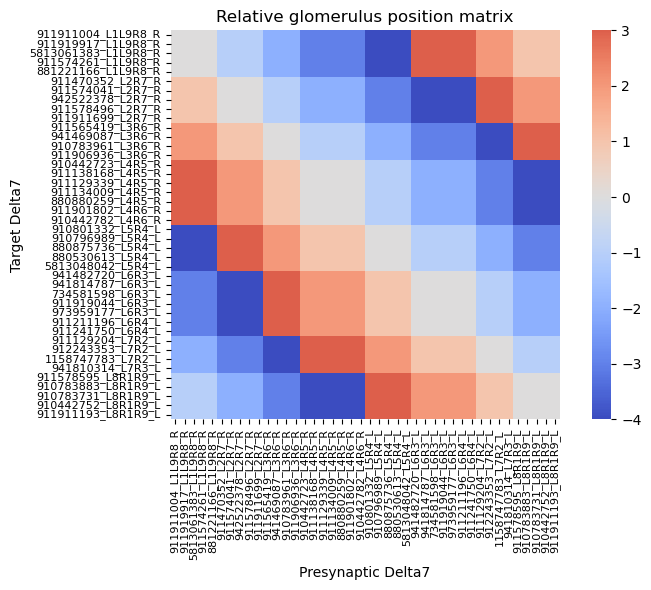

In [40]:
glucl.plot_matrix_heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Relative glomerulus position matrix",
)

In [12]:
# this cell uses the skeleton matrix
# and fill in the "normalized v5 tagged glucla expression"

d7_glucl_matrix_percentage_total_green = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:942: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


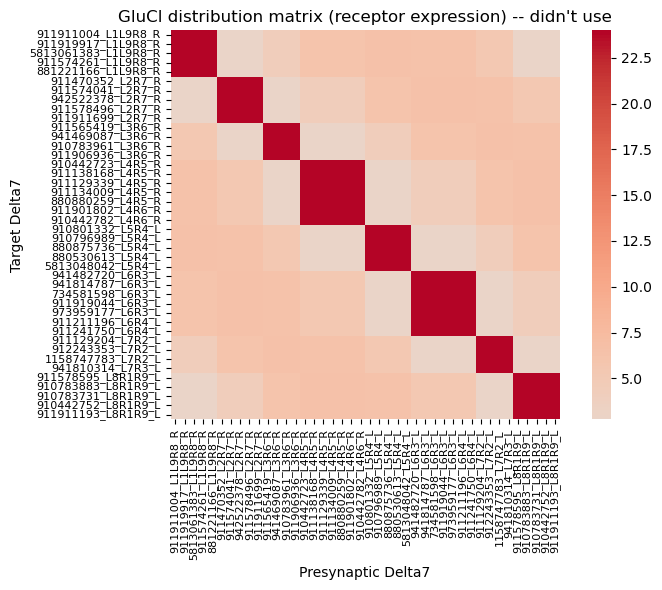

In [35]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_percentage_total_green,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="GluCl distribution matrix (receptor expression) -- didn't use",
)

In [14]:
# this cell uses the skeleton matrix
# and fill in the "normalized v5 tagged glucla expression divided by mean synapse count"

d7_glucl_matrix_d7norm = (
    glucl.map_relative_matrix_to_summary_values(
        relative_matrix=d7_relative_glomerulus_matrix,
        summary_df=summary_df,
        value_col="percentage_total_green_divided_by_d7countall",
        glomerulus_col="glomerulus",
        drop_glomerulus=4,
    )
)

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:942: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: value_map.get(x, np.nan))


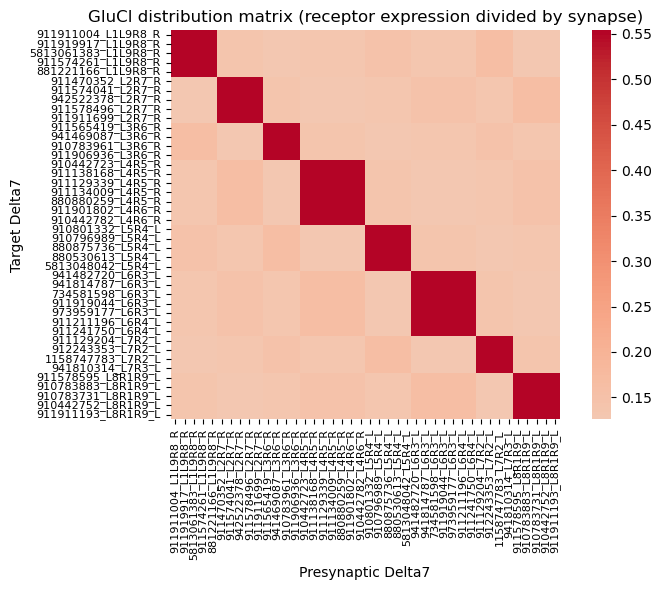

In [28]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="GluCl distribution matrix (receptor expression divided by synapse)",
)

In [16]:
# add the glucl receptor distribution into the synapse count matrix
d7_input_matrix_glucl_receptor = (d7_input_matrix * d7_glucl_matrix_percentage_total_green)

d7_input_matrix_glucl_receptor_by_synapse = (d7_input_matrix * d7_glucl_matrix_d7norm)

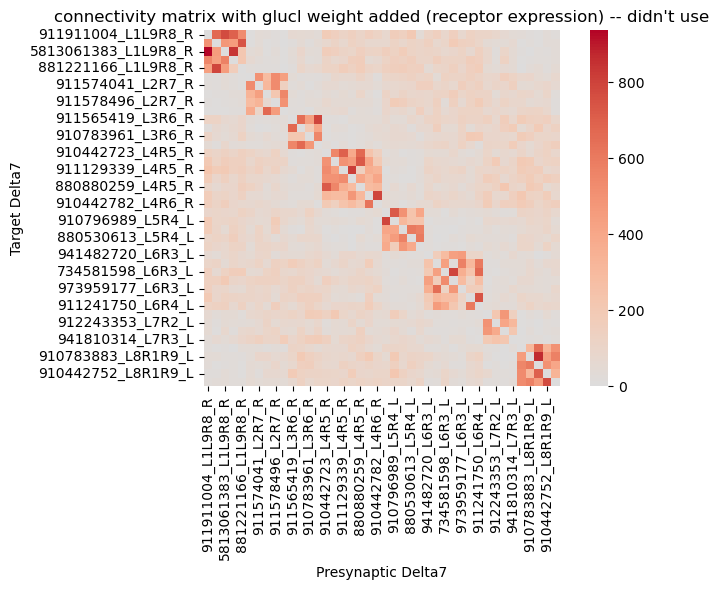

In [41]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor expression) -- didn't use")
plt.tight_layout()
plt.show()

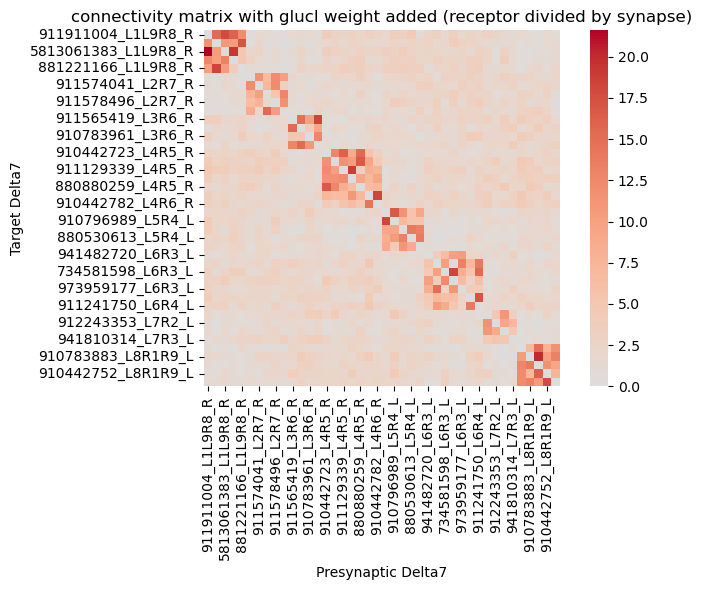

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_input_matrix_glucl_receptor_by_synapse,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("connectivity matrix with glucl weight added (receptor divided by synapse)")
plt.tight_layout()
plt.show()

In [ ]:
# this cell creates 2 matrix containing the "glucla abundance per synapses"
# one matrix contains only axonal values
# the other matrix contains dendritic values

d7_glucl_matrix_d7norm_axon = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix == 0,
        0,
    )
)

d7_glucl_matrix_d7norm_dendrite = (
    d7_glucl_matrix_d7norm.where(
        d7_relative_glomerulus_matrix != 0,
        0,
    )
)

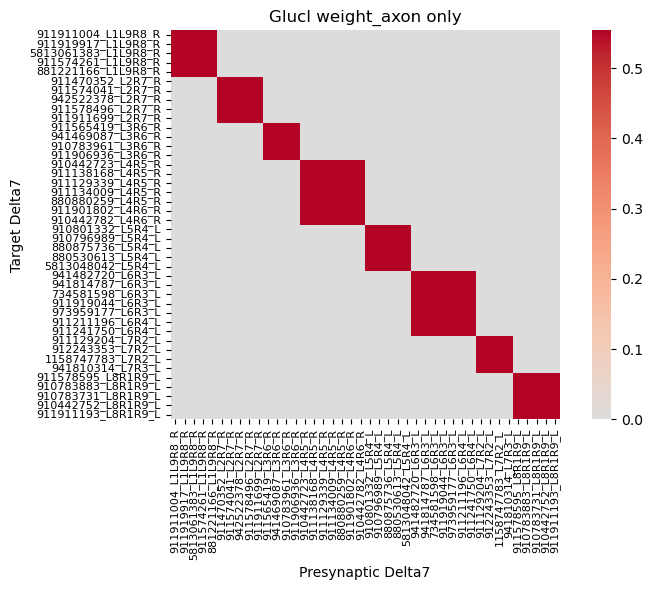

In [30]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

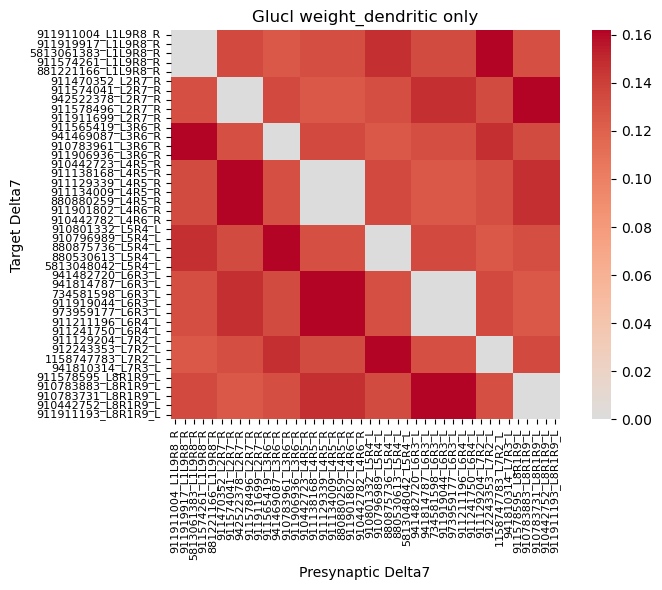

In [43]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_dendritic only",
)

In [44]:
# this cells adds the "glucla abundance per synapse" into the connectivity matrix

chloride_influx_axon = d7_input_matrix * d7_glucl_matrix_d7norm_axon
chloride_influx_dendrite = d7_input_matrix * d7_glucl_matrix_d7norm_dendrite

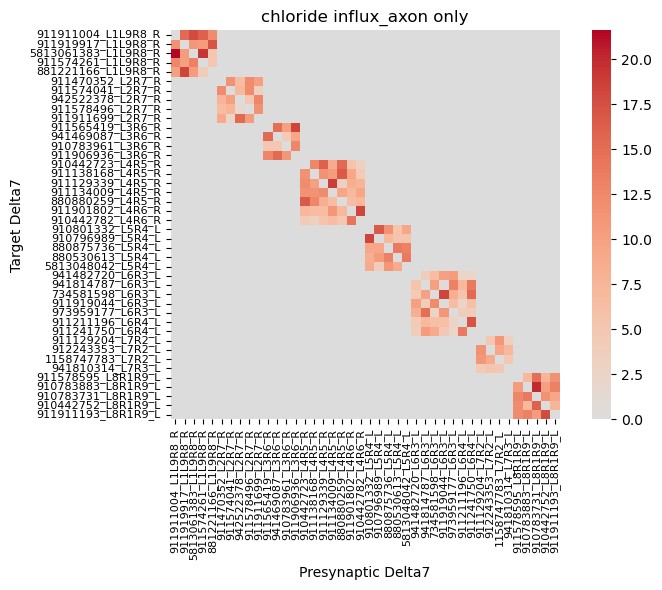

In [45]:
glucl.plot_matrix_heatmap(
    chloride_influx_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_axon only",
)

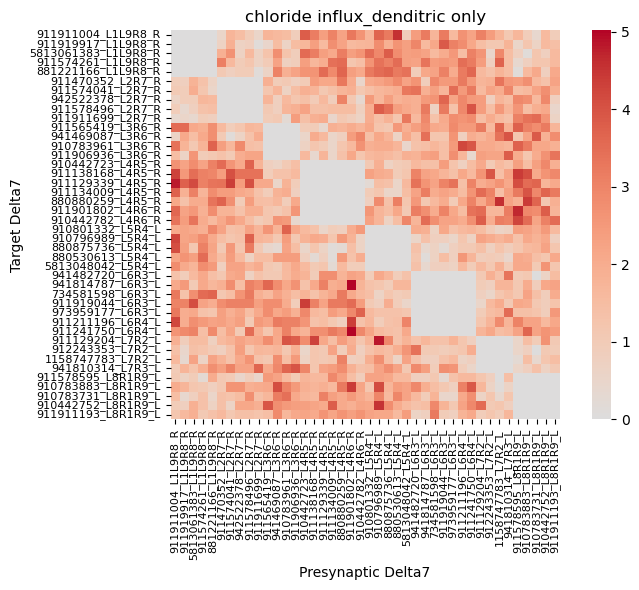

In [46]:
glucl.plot_matrix_heatmap(
    chloride_influx_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_denditric only",
)

Cosine bump values:
[1.    0.854 0.5   0.146 0.    0.146 0.5   0.854]


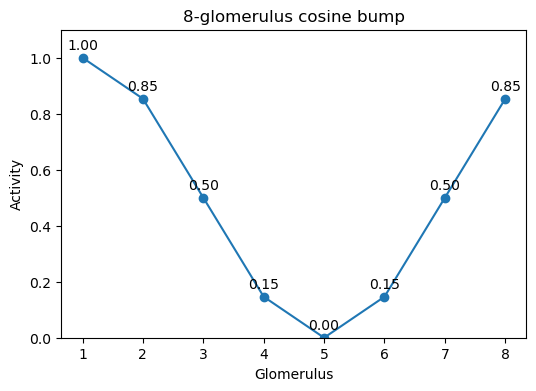

In [47]:
# make a cosine bump with T=8 (8 glomeruli). endpoint should be True because glomerulu 1 and 8 represent different angles
# verified by Cheng lyu 2022 Extended Data Fig.5d

n_gloms = 8
theta = np.linspace(0, 2*np.pi, n_gloms, endpoint=False)
# just label them 1~8
x = np.arange(1, n_gloms + 1)


center = 0  # bump center angle
cos_raw = np.cos(theta - center)

# normalize to 0~1
cos_bump = (cos_raw - cos_raw.min()) / (cos_raw.max() - cos_raw.min())  #<-- this is an array

print("Cosine bump values:")
print(np.round(cos_bump, 3))

plt.figure(figsize=(6,4))
plt.plot(
    x,
    cos_bump,
    marker="o",)
# show values on plot
for xi, yi in zip(x, cos_bump):
    plt.text(
        xi,
        yi + 0.03,
        f"{yi:.2f}",
        ha="center",)
plt.xticks(x)
plt.ylim(0, 1.1)
plt.xlabel("Glomerulus")
plt.ylabel("Activity")
plt.title("8-glomerulus cosine bump")
plt.show()

In [48]:
d7_bump_locations = glucl.map_relative_matrix_to_cosine_bump(
    relative_matrix=d7_relative_glomerulus_matrix,
    cos_bump_array=cos_bump,
)

d7_bump_locations.head()

/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py:992: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  out = out.applymap(lambda x: relative_to_bump.get(int(x), np.nan))


,911911004_L1L9R8_R,911919917_L1L9R8_R,5813061383_L1L9R8_R,911574261_L1L9R8_R,881221166_L1L9R8_R,911470352_L2R7_R,911574041_L2R7_R,942522378_L2R7_R,911578496_L2R7_R,911911699_L2R7_R,...,911241750_L6R4_L,911129204_L7R2_L,912243353_L7R2_L,1158747783_L7R2_L,941810314_L7R3_L,911578595_L8R1R9_L,910783883_L8R1R9_L,910783731_L8R1R9_L,910442752_L8R1R9_L,911911193_L8R1R9_L
911911004_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911919917_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
5813061383_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
911574261_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553
881221166_L1L9R8_R,1.0,1.0,1.0,1.0,1.0,0.853553,0.853553,0.853553,0.853553,0.853553,...,0.146447,0.5,0.5,0.5,0.5,0.853553,0.853553,0.853553,0.853553,0.853553


In [49]:
# this cell prepares the bump location matrix into a format 
# that is easier to multiply to the 2 chloride_influx matrices

d7_bump_locations_glomlabels = d7_bump_locations.copy()

new_labels = [
    str(x).split("_", 1)[1][:2]
    for x in d7_bump_locations.index
]

d7_bump_locations_glomlabels.index = new_labels
d7_bump_locations_glomlabels.columns = new_labels


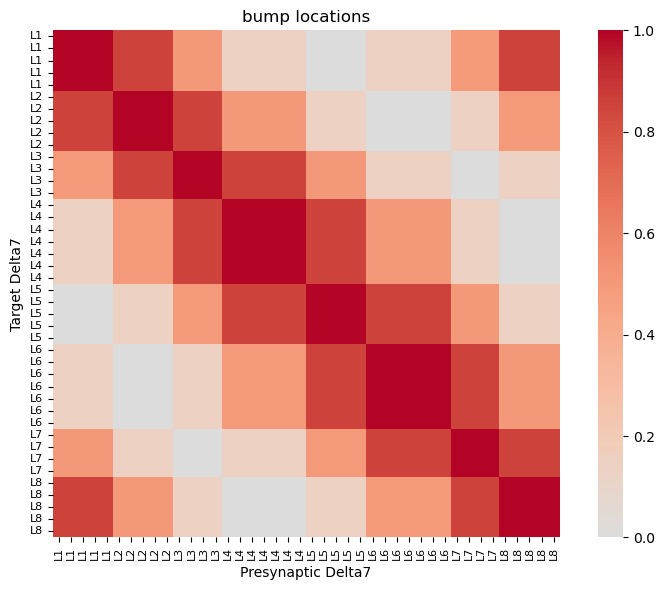

In [50]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations",
)

In [51]:
keep_cols = ~d7_bump_locations_glomlabels.columns.duplicated(keep="first")

d7_bump_locations_glomlabels_condensed = (
    d7_bump_locations_glomlabels
    .loc[:, keep_cols]
)

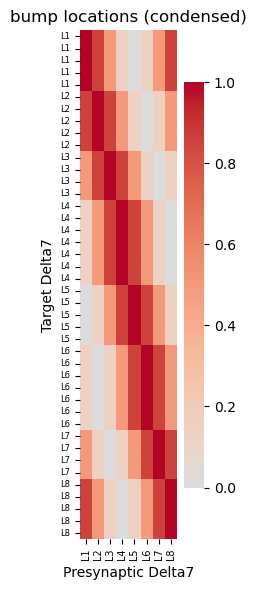

In [52]:
glucl.plot_matrix_heatmap(
    d7_bump_locations_glomlabels_condensed,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(2, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="bump locations (condensed)",
    xtick_fontsize=7,
    ytick_fontsize=6,
)

explanation for the below cell: first, outside loop through all columns in inhibition_matrix, second, inside loop through all columns in bump_matrix_colcondensed.

For the first column in inhibition_matrix, it will first multiply with the first column in bump_matrix_colcondensed (so neuron 911911004_L1L9R8_R in either axon-only matrix or dendrite-only matrix multiply the bump with its peak at glomerulus 1) **element-wise** and obtain 42 numbers. Then sum these 42 numbers. Then multiply this column in inhibition_matrix with the second column in bump_matrix_colcondensed and obtain the second sum. In this way there will be 8 sums, and these 8 numbers are stored as **row** one (for neuron 911911004_L1L9R8_R) in the the resulting matrix.
Then loop to the second column in inhibition_matrix and obtain the second **row** in the resulting matrix.

In this way, if inhibition_matrix is chloride_influx_axon, which only includes synapse count with glucl weight for axonal glomeruli, the resulting matrix (axo_axonal_cl_inhibition) tells you that for each cell, what are the chloride inhibition its one axonal glomerulus receive when the bump peak is at glomerulus 1...glomerulus 8. If inhibition_matrix is axo_dendritic_cl_inhibition, then the resulting matrix (axo_dendritic_cl_inhibition) tells you that for each cell, what are the chloride inhibtion all of its 7 dendritic glomeruli recieve when the bump peak is at glomerulus 1...glomerulus 8.

In [53]:
axo_axonal_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_axon,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

q: something is wrong here...why is each curve in axon symmetric? the dendritic ones aren't...

A: this is correct. axon curves is made from using the same number multiply the cosine bump. because the bump is symmetric, the resulting curve will be symmetric. This is different from dendritic because the numbers getting multiplied at a given bumpm position is different.

In [54]:
axo_axonal_cl_inhibition.head()

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,55.953833,47.759584,27.976917,8.194249,0.0,8.194249,27.976917,47.759584
911919917_L1L9R8_R,54.291838,46.340983,27.145919,7.950856,0.0,7.950856,27.145919,46.340983
5813061383_L1L9R8_R,52.629843,44.922381,26.314922,7.707462,0.0,7.707462,26.314922,44.922381
911574261_L1L9R8_R,49.859852,42.558045,24.929926,7.301806,0.0,7.301806,24.929926,42.558045
881221166_L1L9R8_R,39.333883,33.573569,19.666941,5.760314,0.0,5.760314,19.666941,33.573569


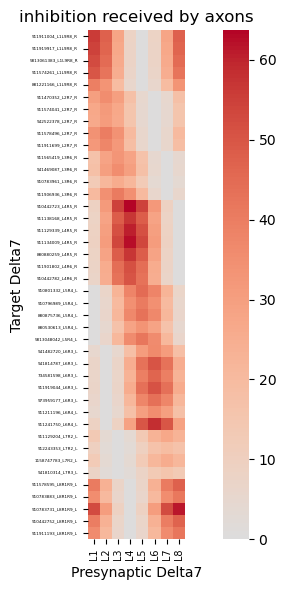

In [57]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

Logically the same as making axo_axonal_cl_inhibition. Since at a given bump peak location, after multiplying the inhibition_matrix with bump_matrix_colcondensed element-wisely, I summed the 42 numbers, the resulting matrix means when the bump is at a given location, what is the total dendritic chloride inhibition the cell receives.

To make sense of the x axis (bump peak glomerular position), I can still think of it as "when the bump peak is at this amount of glomerular distance to the axonal glomerulus of this cell, what is the total dendritic chloride inhibition this cell receives?".

In [58]:
axo_dendritic_cl_inhibition = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=chloride_influx_dendrite,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

In [59]:
axo_dendritic_cl_inhibition.head()

,L1,L2,L3,L4,L5,L6,L7,L8
source,,,,,,,,
911911004_L1L9R8_R,23.092521,30.445072,45.008579,58.251938,62.417367,55.064816,40.501309,27.257951
911919917_L1L9R8_R,17.847944,23.475526,33.772514,42.707074,45.045461,39.417880,29.120892,20.186332
5813061383_L1L9R8_R,23.291906,28.517320,38.934102,48.440241,51.467172,46.241757,35.824976,26.318836
911574261_L1L9R8_R,20.458732,25.623555,35.988534,45.482003,48.542818,43.377995,33.013016,23.519547
881221166_L1L9R8_R,22.544658,29.174278,40.475515,49.828257,51.753794,45.124173,33.822937,24.470195


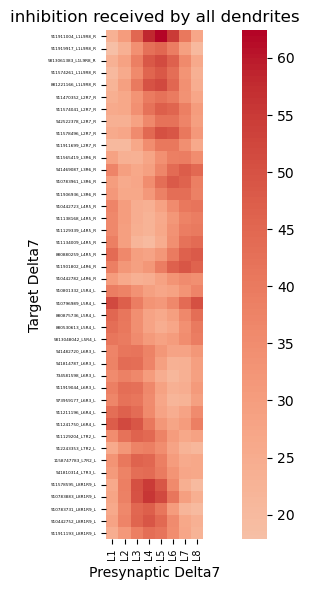

In [60]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

In [67]:
axo_axonal_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_axonal_cl_inhibition,
    target_idx=4,
)
axo_dendritic_cl_inhibition_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_dendritic_cl_inhibition,
    target_idx=4,
)

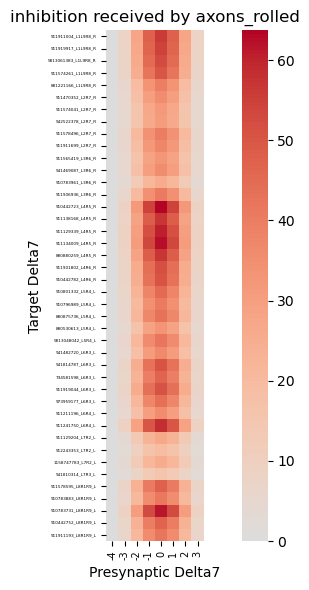

In [68]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons_rolled",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

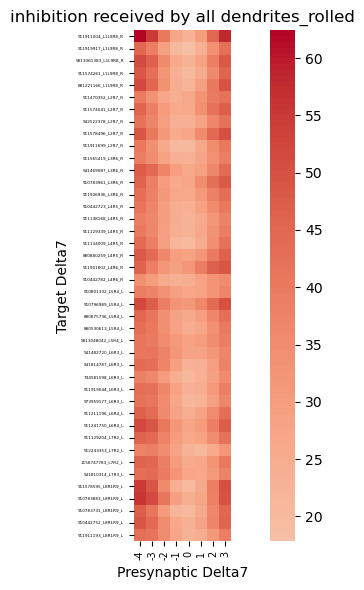

In [69]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites_rolled",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

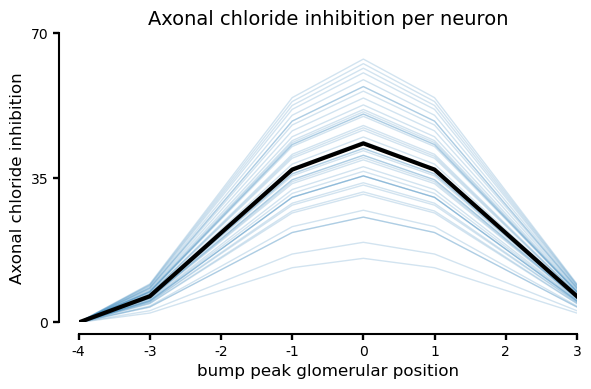

In [70]:
glucl.plot_each_row_as_line(
    axo_axonal_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Axonal chloride inhibition",
    xlabel="bump peak glomerular position",
    title="Axonal chloride inhibition per neuron",
    ytick_decimals=0,
    y_min_mode="data",
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
)

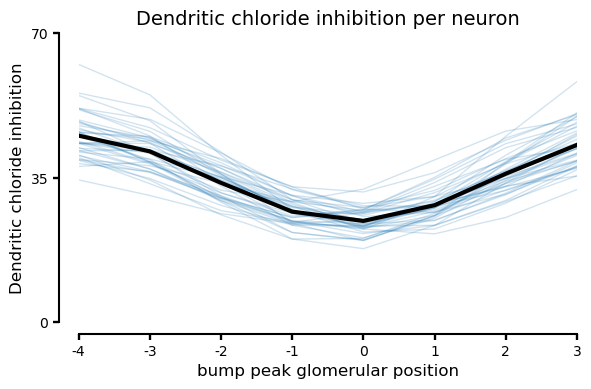

In [71]:
glucl.plot_each_row_as_line(
    axo_dendritic_cl_inhibition_rolled,
    color="tab:blue",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Dendritic chloride inhibition",
    xlabel="bump peak glomerular position",
    title="Dendritic chloride inhibition per neuron",
    ytick_decimals=0,
    y_min_mode="zero",      # of 'data'
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
    y_max_pad_frac=0.05,
)

In [72]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

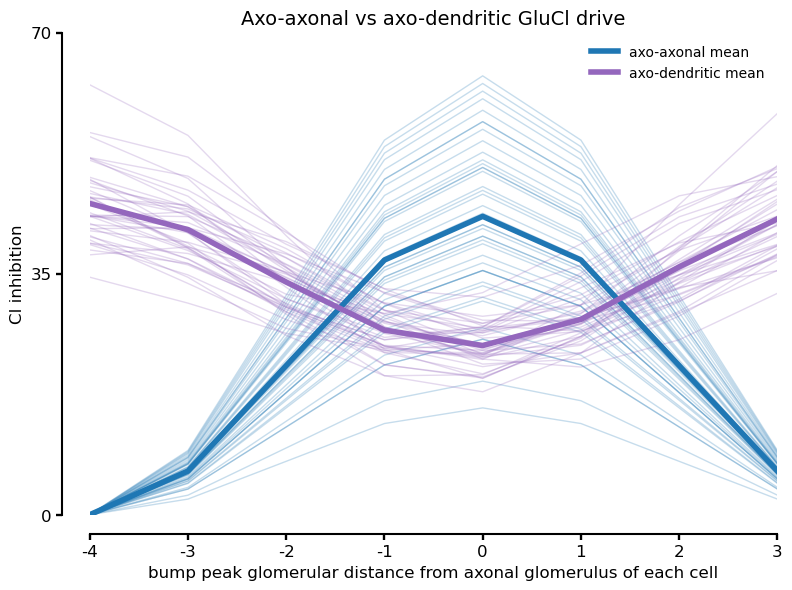

In [73]:
glucl.plot_two_dfs_each_row_as_line(
    axo_axonal_cl_inhibition_rolled,
    axo_dendritic_cl_inhibition_rolled,
    figsize=(8, 6),
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=12,
    legend_fontsize=10,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axo-axonal mean",
    df2_label="axo-dendritic mean",
    alpha=0.25,
    linewidth=1,
    mean_linewidth=4,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Axo-axonal vs axo-dendritic GluCl drive",
    y_min_mode="zero",
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
)

In [74]:
combined_cl_inhibition_rolled = (
    axo_axonal_cl_inhibition_rolled +
    axo_dendritic_cl_inhibition_rolled)

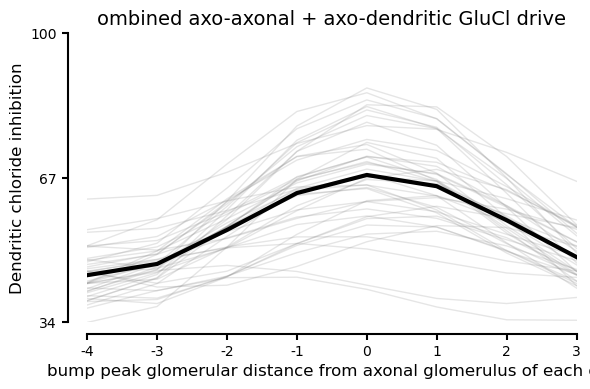

In [76]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled,
    color="gray",
    alpha=0.2,
    mean_color="black",
    figsize=(6, 4),
    ylabel="Dendritic chloride inhibition",
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    title="ombined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="data",
    ytick_decimals=0,
)

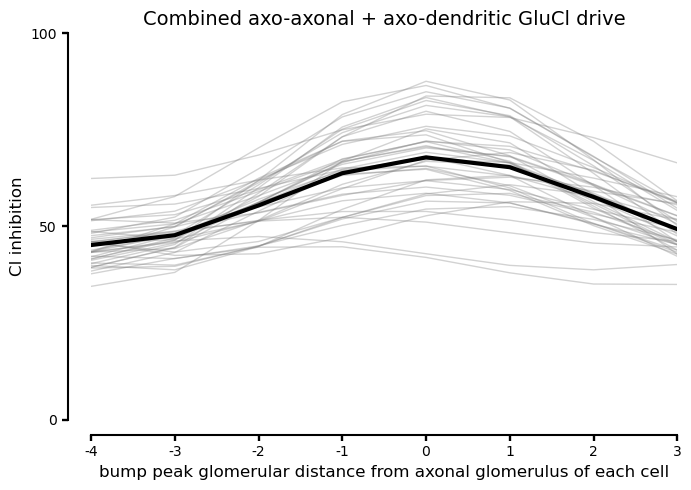

In [213]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled,
    color="gray",
    alpha=0.35,
    linewidth=1,
    mean_color="black",
    mean_linewidth=3,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Combined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="zero",   # bottom y tick is 0
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
    save_svg=project_root / "results" / "plots" / "combined_glucl_drive.svg"
)

In [ ]:
# roll the columns so that the axonal glomerulus is now on the leftmost

axo_axonal_cl_inhibition_rolled2 = axo_axonal_cl_inhibition_rolled.copy()
axo_axonal_cl_inhibition_rolled2 = axo_axonal_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(axo_axonal_cl_inhibition_rolled2.shape[1]), -4)]

axo_dendritic_cl_inhibition_rolled2 = axo_dendritic_cl_inhibition_rolled.copy()
axo_dendritic_cl_inhibition_rolled2 = axo_dendritic_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(axo_dendritic_cl_inhibition_rolled2.shape[1]), -4)]

combined_cl_inhibition_rolled2 = combined_cl_inhibition_rolled.copy()
combined_cl_inhibition_rolled2 = combined_cl_inhibition_rolled2.iloc[
    :,
    np.roll(np.arange(combined_cl_inhibition_rolled2.shape[1]), -4)]

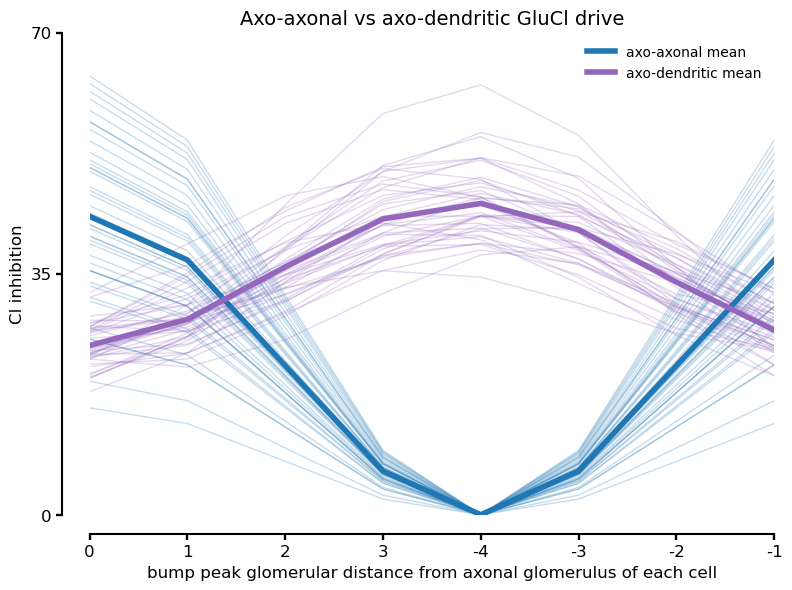

In [178]:
glucl.plot_two_dfs_each_row_as_line(
    axo_axonal_cl_inhibition_rolled2,
    axo_dendritic_cl_inhibition_rolled2,
    figsize=(8, 6),
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=12,
    legend_fontsize=10,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axo-axonal mean",
    df2_label="axo-dendritic mean",
    alpha=0.25,
    linewidth=1,
    mean_linewidth=4,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Axo-axonal vs axo-dendritic GluCl drive",
    y_min_mode="zero",
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
)

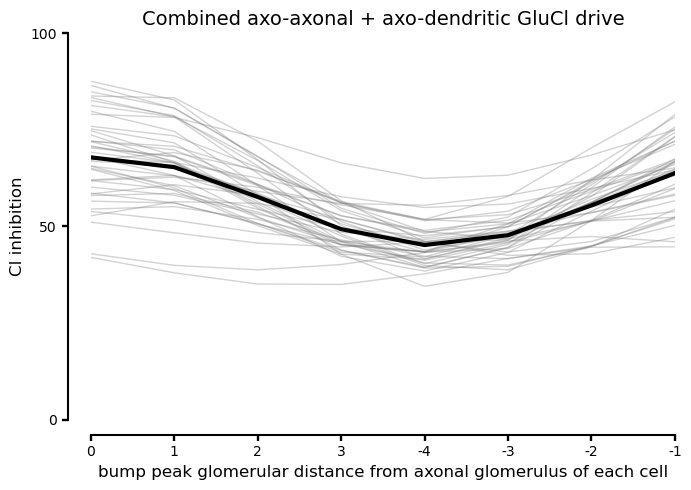

In [ ]:
glucl.plot_each_row_as_line(
    combined_cl_inhibition_rolled2,
    color="gray",
    alpha=0.35,
    linewidth=1,
    mean_color="black",
    mean_linewidth=3,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Combined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="zero",   # bottom y tick is 0
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
)

In [180]:
axo_dendritic_cl_inhibition.index

Index(['911911004_L1L9R8_R', '911919917_L1L9R8_R', '5813061383_L1L9R8_R',
       '911574261_L1L9R8_R', '881221166_L1L9R8_R', '911470352_L2R7_R',
       '911574041_L2R7_R', '942522378_L2R7_R', '911578496_L2R7_R',
       '911911699_L2R7_R', '911565419_L3R6_R', '941469087_L3R6_R',
       '910783961_L3R6_R', '911906936_L3R6_R', '910442723_L4R5_R',
       '911138168_L4R5_R', '911129339_L4R5_R', '911134009_L4R5_R',
       '880880259_L4R5_R', '911901802_L4R6_R', '910442782_L4R6_R',
       '910801332_L5R4_L', '910796989_L5R4_L', '880875736_L5R4_L',
       '880530613_L5R4_L', '5813048042_L5R4_L', '941482720_L6R3_L',
       '941814787_L6R3_L', '734581598_L6R3_L', '911919044_L6R3_L',
       '973959177_L6R3_L', '911211196_L6R4_L', '911241750_L6R4_L',
       '911129204_L7R2_L', '912243353_L7R2_L', '1158747783_L7R2_L',
       '941810314_L7R3_L', '911578595_L8R1R9_L', '910783883_L8R1R9_L',
       '910783731_L8R1R9_L', '910442752_L8R1R9_L', '911911193_L8R1R9_L'],
      dtype='object', name='source')

In [181]:
axo_axonal_cl_inhibition_rolled.loc['911129204_L7R2_L']

-4     0.000000
-3     3.975428
-2    13.572960
-1    23.170491
 0    27.145919
 1    23.170491
 2    13.572960
 3     3.975428
Name: 911129204_L7R2_L, dtype: float64

In [182]:
axo_dendritic_cl_inhibition_rolled.loc["911129204_L7R2_L"]

-4    46.109090
-3    44.388793
-2    38.000663
-1    30.686779
 0    26.731515
 1    28.451812
 2    34.839943
 3    42.153827
Name: 911129204_L7R2_L, dtype: float64

'''this cell makes a plot for each cell (n=42)'''
glucl.plot_each_cell_two_lines(
    df1=axo_axonal_cl_inhibition_rolled,
    df2=axo_dendritic_cl_inhibition_rolled,
    df1_color="tab:blue",
    df2_color="purple",
    df1_label="axonal",
    df2_label="dendritic",
    ylabel="Chloride inhibition",
    title_prefix="Cell: ",
)

In [107]:
importlib.reload(glucl)

<module 'lib_glucl_drive' from '/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/send_to_fisherlabgithub/library/lib_glucl_drive.py'>

# same analysis but WITHOUT adding "glucla abundance per synapse"

In [77]:
d7_matrix_axon = (
    d7_input_matrix.where(
        d7_relative_glomerulus_matrix == 0,
        0,
    )
)

d7_matrix_dendrite = (
    d7_input_matrix.where(
        d7_relative_glomerulus_matrix != 0,
        0,
    )
)

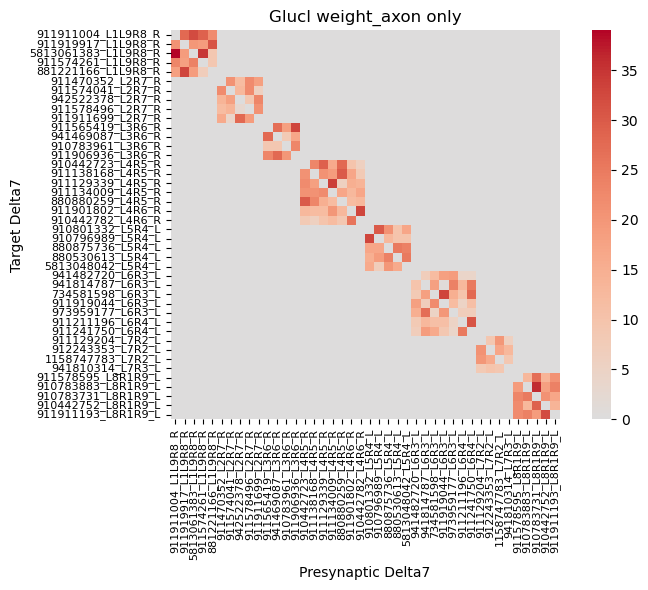

In [78]:
glucl.plot_matrix_heatmap(
    d7_matrix_axon,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

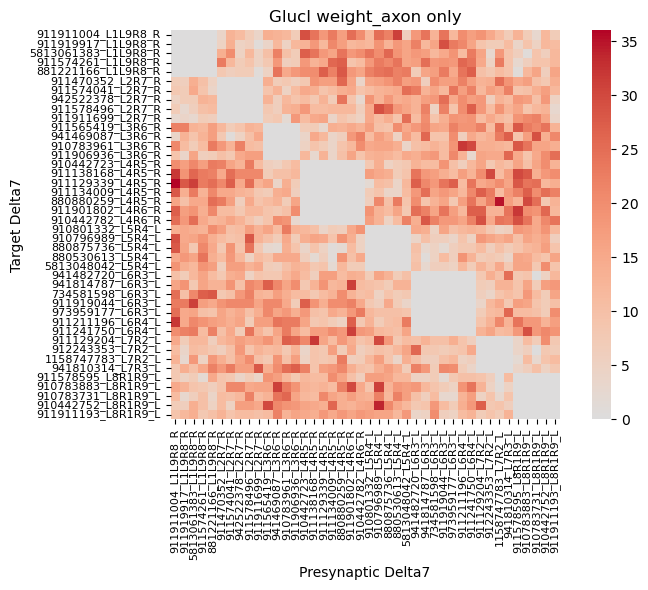

In [79]:
glucl.plot_matrix_heatmap(
    d7_matrix_dendrite,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

notes for me...\
chloride_influx_axon = d7_matrix_axon\
chloride_influx_dendrite = d7_matrix_dendrite

In [134]:
axo_axonal_inhibition_synapseonly = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=d7_matrix_axon,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

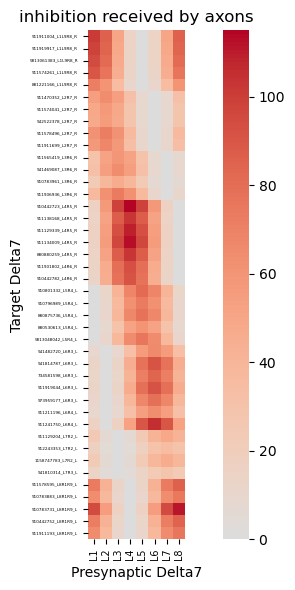

In [192]:
glucl.plot_matrix_heatmap(
    axo_axonal_inhibition_synapseonly,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

In [138]:
axo_dendritic_inhibition_synapseonly = glucl.project_inhibition_onto_bump_columns(
    inhibition_matrix=d7_matrix_dendrite,
    bump_matrix_colcondensed=d7_bump_locations_glomlabels_condensed,
)

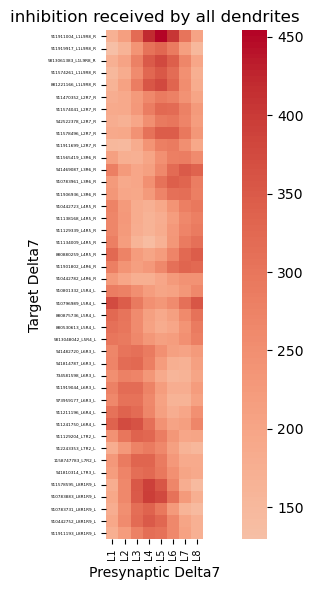

In [191]:
glucl.plot_matrix_heatmap(
    axo_dendritic_inhibition_synapseonly,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

notes for me...\
axo_axonal_cl_inhibition = axo_axonal_inhibition_synapseonly\
axo_dendritic_cl_inhibition = axo_dendritic_inhibition_synapseonly

In [140]:
axo_axonal_inhibition_synapseonly_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_axonal_inhibition_synapseonly,
    target_idx=4,
)
axo_dendritic_inhibition_synapseonly_rolled = glucl.roll_each_row_to_center_glomerulus(
    axo_dendritic_inhibition_synapseonly,
    target_idx=4,
)

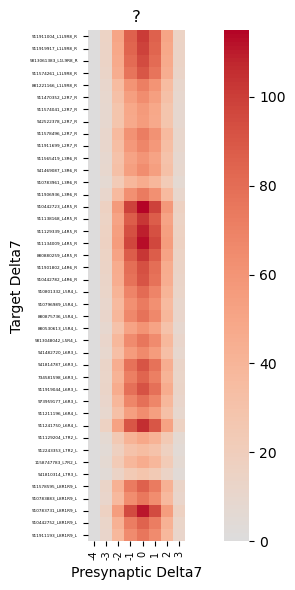

In [187]:
glucl.plot_matrix_heatmap(
    axo_axonal_inhibition_synapseonly_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

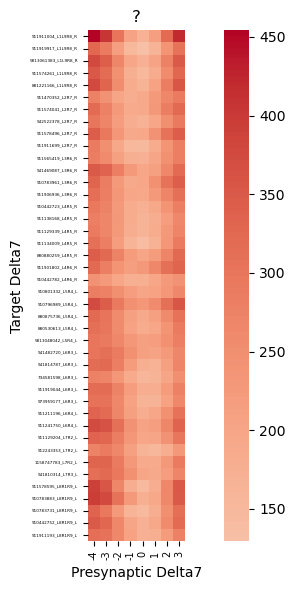

In [142]:
glucl.plot_matrix_heatmap(
    axo_dendritic_inhibition_synapseonly_rolled,
    cmap="coolwarm",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="?",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

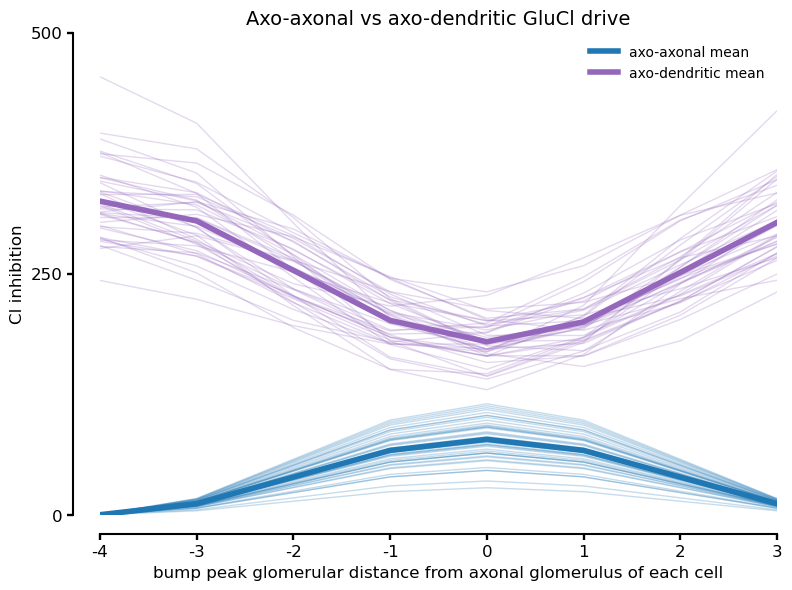

In [143]:
glucl.plot_two_dfs_each_row_as_line(
    axo_axonal_inhibition_synapseonly_rolled,
    axo_dendritic_inhibition_synapseonly_rolled,
    figsize=(8, 6),
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=12,
    legend_fontsize=10,
    df1_color="tab:blue",
    df2_color="tab:purple",
    df1_label="axo-axonal mean",
    df2_label="axo-dendritic mean",
    alpha=0.25,
    linewidth=1,
    mean_linewidth=4,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Axo-axonal vs axo-dendritic GluCl drive",
    y_min_mode="zero",
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
)

In [144]:
combined_inhibition_synapseonly_rolled = (
    axo_axonal_inhibition_synapseonly_rolled +
    axo_dendritic_inhibition_synapseonly_rolled)

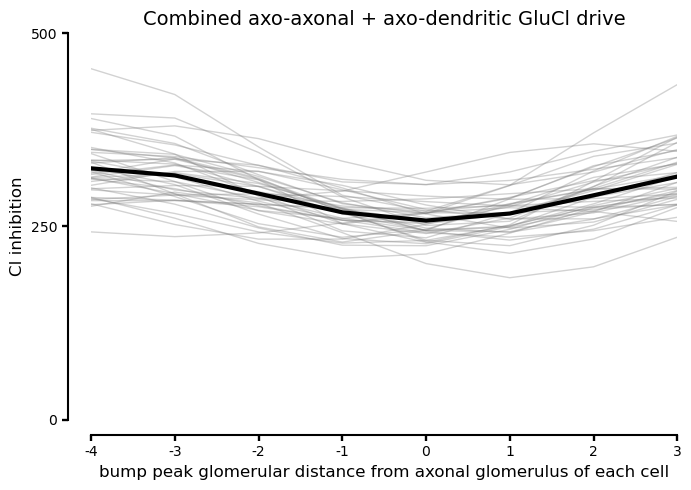

In [214]:
glucl.plot_each_row_as_line(
    combined_inhibition_synapseonly_rolled,
    color="gray",
    alpha=0.35,
    linewidth=1,
    mean_color="black",
    mean_linewidth=3,
    marker="o",
    marker_size=0,
    xlabel="bump peak glomerular distance from axonal glomerulus of each cell",
    ylabel="Cl inhibition",
    title="Combined axo-axonal + axo-dendritic GluCl drive",
    y_min_mode="zero",   # bottom y tick is 0
    ytick_decimals=0,
    tick_length=4,
    tick_width=1.7,
    axis_linewidth=1.5,
    title_fontsize=14,
    axis_label_size=12,
    tick_label_size=10,
    legend_fontsize=10,
    save_svg=project_root / "results" / "plots" / "combined_glucl_drive_noglucl.svg"

)

# change the color of the matrices made above

In [193]:
from matplotlib import colormaps

list(colormaps)


['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

with glucl weight section

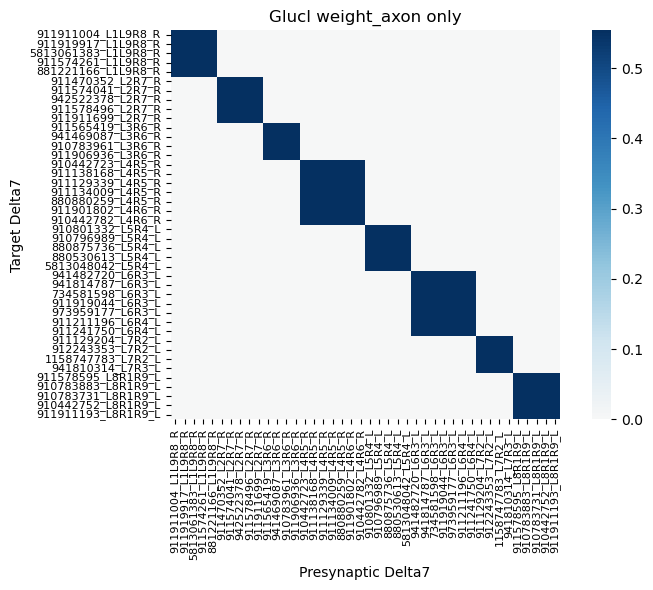

In [205]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_axon,
    cmap="RdBu",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_axon only",
)

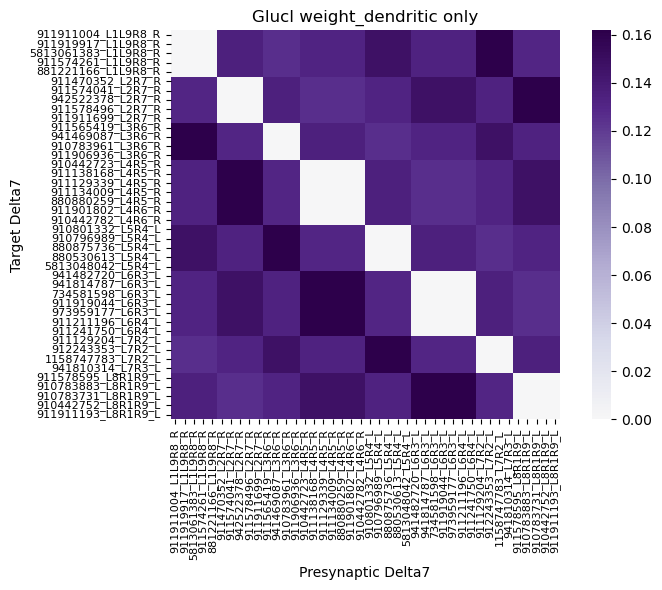

In [206]:
glucl.plot_matrix_heatmap(
    d7_glucl_matrix_d7norm_dendrite,
    cmap="PuOr",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="Glucl weight_dendritic only",
)

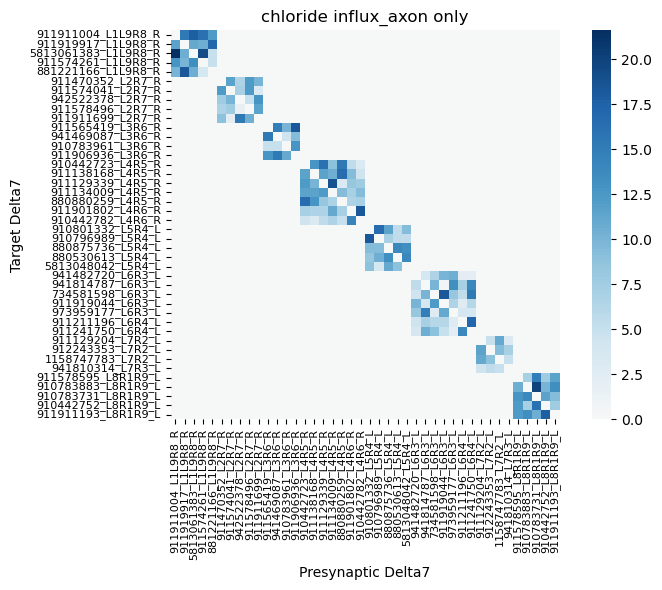

In [207]:
glucl.plot_matrix_heatmap(
    chloride_influx_axon,
    cmap="RdBu",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_axon only",
)

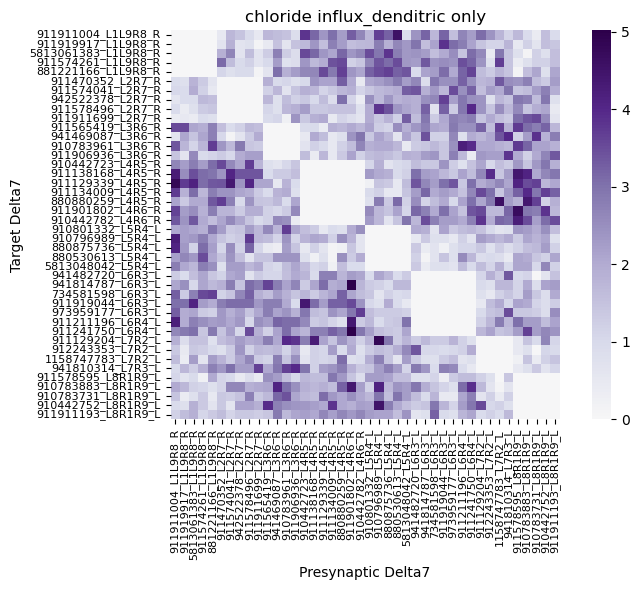

In [208]:
glucl.plot_matrix_heatmap(
    chloride_influx_dendrite,
    cmap="PuOr",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="chloride influx_denditric only",
)

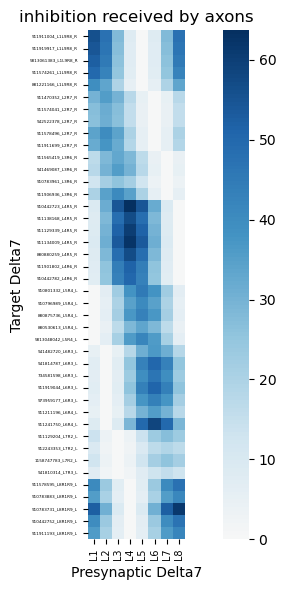

In [210]:
glucl.plot_matrix_heatmap(
    axo_axonal_cl_inhibition,
    cmap="RdBu",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by axons",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

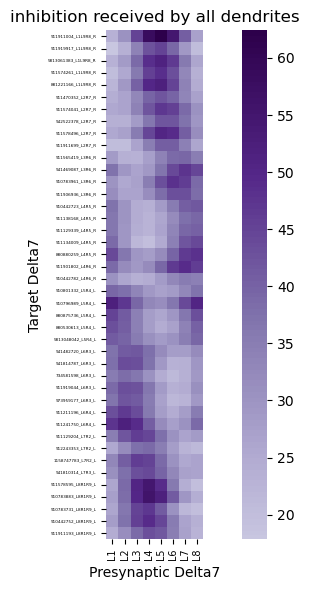

In [211]:
glucl.plot_matrix_heatmap(
    axo_dendritic_cl_inhibition,
    cmap="PuOr",
    center=0,
    square=True,
    figsize=(8, 6),
    xlabel="Presynaptic Delta7",
    ylabel="Target Delta7",
    title="inhibition received by all dendrites",
    xtick_fontsize=7,
    ytick_fontsize=3,
)

# draft (confirming the functions work as they should)

1. roll_matrix_columns_to_center_zero

In [109]:
d7_relative_glomerulus_matrix.columns

Index(['911911004_L1L9R8_R', '911919917_L1L9R8_R', '5813061383_L1L9R8_R',
       '911574261_L1L9R8_R', '881221166_L1L9R8_R', '911470352_L2R7_R',
       '911574041_L2R7_R', '942522378_L2R7_R', '911578496_L2R7_R',
       '911911699_L2R7_R', '911565419_L3R6_R', '941469087_L3R6_R',
       '910783961_L3R6_R', '911906936_L3R6_R', '910442723_L4R5_R',
       '911138168_L4R5_R', '911129339_L4R5_R', '911134009_L4R5_R',
       '880880259_L4R5_R', '911901802_L4R6_R', '910442782_L4R6_R',
       '910801332_L5R4_L', '910796989_L5R4_L', '880875736_L5R4_L',
       '880530613_L5R4_L', '5813048042_L5R4_L', '941482720_L6R3_L',
       '941814787_L6R3_L', '734581598_L6R3_L', '911919044_L6R3_L',
       '973959177_L6R3_L', '911211196_L6R4_L', '911241750_L6R4_L',
       '911129204_L7R2_L', '912243353_L7R2_L', '1158747783_L7R2_L',
       '941810314_L7R3_L', '911578595_L8R1R9_L', '910783883_L8R1R9_L',
       '910783731_L8R1R9_L', '910442752_L8R1R9_L', '911911193_L8R1R9_L'],
      dtype='object')

In [110]:
rel_col = d7_relative_glomerulus_matrix['911911004_L1L9R8_R'].to_numpy()
rel_col

array([ 0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,
        2.,  3.,  3.,  3.,  3.,  3.,  3.,  3., -4., -4., -4., -4., -4.,
       -3., -3., -3., -3., -3., -3., -3., -2., -2., -2., -2., -1., -1.,
       -1., -1., -1.])

In [111]:
zero_value=0

In [112]:
zero_positions = np.where(rel_col == zero_value)[0]
zero_positions

array([0, 1, 2, 3, 4])

In [113]:
chosen_zero_pos = zero_positions[len(zero_positions) // 2]
chosen_zero_pos

2

In [114]:
center_idx = len(d7_relative_glomerulus_matrix)//2
center_idx

21

In [115]:
shift = center_idx - chosen_zero_pos
shift

19

In [116]:
rel_col

array([ 0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,
        2.,  3.,  3.,  3.,  3.,  3.,  3.,  3., -4., -4., -4., -4., -4.,
       -3., -3., -3., -3., -3., -3., -3., -2., -2., -2., -2., -1., -1.,
       -1., -1., -1.])

In [117]:
column_tep = d7_relative_glomerulus_matrix['911911004_L1L9R8_R']
column_col = np.roll(column_tep.to_numpy(), shift,)
column_col

array([-4., -4., -4., -3., -3., -3., -3., -3., -3., -3., -2., -2., -2.,
       -2., -1., -1., -1., -1., -1.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,
        1.,  1.,  1.,  2.,  2.,  2.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,
        3., -4., -4.])

2. project_inhibition_onto_bump_columns

In [118]:
a= chloride_influx_axon['911911004_L1L9R8_R'].to_numpy()
a

array([ 0.        , 11.63396538, 21.6059357 , 12.74196208,  9.97197032,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ])

In [119]:
b=d7_bump_locations_glomlabels_condensed['L1'].to_numpy()
b

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       0.85355339, 0.85355339, 0.85355339, 0.85355339, 0.85355339,
       0.5       , 0.5       , 0.5       , 0.5       , 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.14644661, 0.14644661, 0.14644661, 0.14644661,
       0.14644661, 0.14644661, 0.14644661, 0.5       , 0.5       ,
       0.5       , 0.5       , 0.85355339, 0.85355339, 0.85355339,
       0.85355339, 0.85355339])

In [120]:
c=np.nansum(a*b)
c

55.953833470733706

3. the roll function

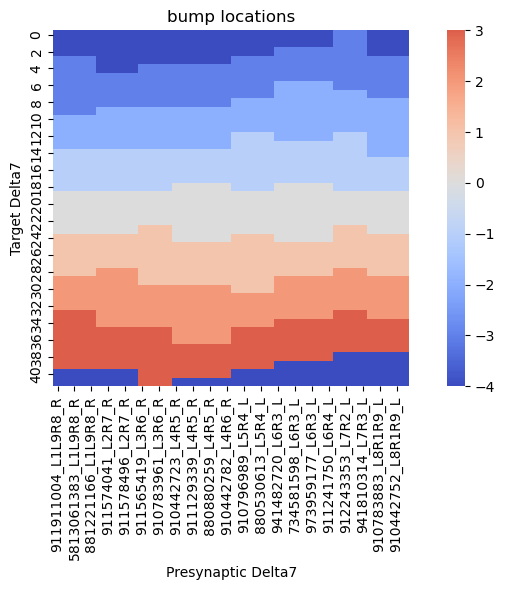

In [22]:
d7_relative_glomerulus_matrix_rolled = (
    glucl.roll_matrix_columns_to_center_zero(
        input_matrix=d7_relative_glomerulus_matrix,
        relative_matrix=d7_relative_glomerulus_matrix,
    )
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix_rolled,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("bump locations")
plt.tight_layout()
plt.show()

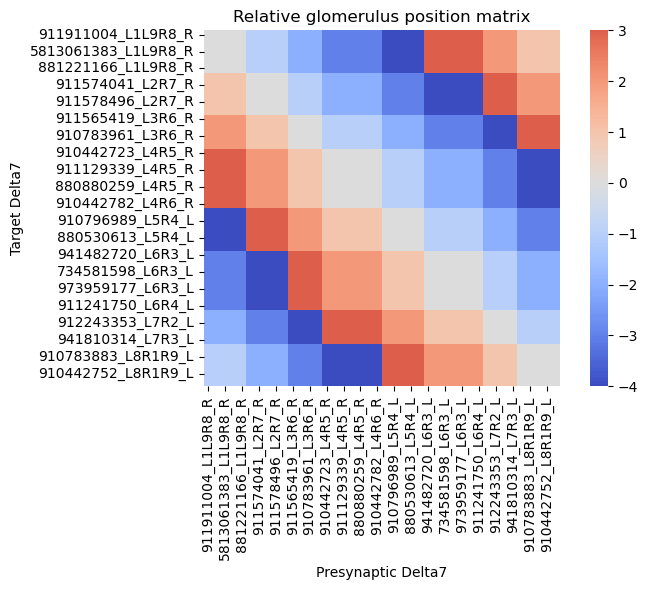

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    d7_relative_glomerulus_matrix,
    cmap="coolwarm",
    center=0,
    square=True,)
plt.xlabel("Presynaptic Delta7")
plt.ylabel("Target Delta7")
plt.title("Relative glomerulus position matrix")
plt.tight_layout()
plt.show()